In [13]:
import pandas as pd
from pathlib import Path
import matplotlib.pyplot as plt
import seaborn as sns
import sys
sys.path.insert(0, str(Path.cwd().parent))
from src.constant import TEXT_TYPE, NUMERIC_TYPE, CSV_SELECTED_NUTRIMENT_COLUMNS, CSV_SELECTED_COLUMNS

NUMERIC = NUMERIC_TYPE + CSV_SELECTED_NUTRIMENT_COLUMNS

### Dimensions, types

In [14]:
df = pd.read_csv(
    # "./../wip/echantillon_france.csv",
    './../wip/openfoodfacts.filtered.csv',
    dtype={c: "string" for c in TEXT_TYPE},
    converters={col: lambda val: pd.to_numeric(val, errors="coerce") for col in NUMERIC}
)

# ligne pnns_groups_1 = 'italie' ???
nb_italie = int((df["pnns_groups_1"] == "italie").sum())
print(f"Nombre de produits dans le groupe 'italie' : {nb_italie}")

print(f"{df.shape[0]} lignes x {df.shape[1]} colonnes")
print(df.dtypes.value_counts())

Nombre de produits dans le groupe 'italie' : 1
1261274 lignes x 33 colonnes
string     17
float64    15
int64       1
Name: count, dtype: int64


### Profil de manquants par colonne (%)

In [15]:
profil = (df.isna().mean() * 100).round(1).sort_values(ascending=False).rename("pct_manquant")
print(profil.to_string())
print(f"{int((profil == 0).sum())} colonnes complètes")

serving_size                      88.5
allergens                         87.6
stores                            82.8
nova_group                        72.7
fruits-vegetables-legumes_100g    72.4
additives_n                       70.7
ingredients_text                  70.7
fiber_100g                        70.2
quantity                          63.4
nutriscore_score                  62.4
labels_tags                       59.4
main_category                     49.7
categories_tags                   49.7
brands                            46.5
salt_100g                         34.9
sodium_100g                       34.9
saturated-fat_100g                30.8
carbohydrates_100g                30.7
sugars_100g                       30.7
fat_100g                          30.7
proteins_100g                     30.6
energy-kcal_100g                  30.1
energy_100g                       30.1
product_name                      10.4
image_url                          7.6
environmental_score_grade

### Manquants par rayon

In [16]:
colonnes = CSV_SELECTED_COLUMNS + CSV_SELECTED_NUTRIMENT_COLUMNS
par_rayon = (df.groupby("pnns_groups_1", dropna=False)[colonnes].apply(lambda g: g.isna().mean() * 100).round(1))
print(par_rayon.T.to_string())

# /!\ Rayon italie ???

pnns_groups_1                   Alcoholic beverages  Baby foods  Beverages  Cereals and potatoes  Composite foods  Fat and sauces  Fish Meat Eggs  Fruits and vegetables  Milk and dairy products  Salty snacks  Sugary snacks  italie  unknown   <NA>
code                                            0.0         0.0        0.0                   0.0              0.0             0.0             0.0                    0.0                      0.0           0.0            0.0     0.0      0.0    0.0
product_name                                    3.4         1.1        2.3                   2.5              1.3             1.8             1.8                    1.6                      2.7           2.0            2.5     0.0     13.9   99.9
brands                                         33.8         2.2       13.3                  17.8             20.1            24.6            34.7                   28.0                     25.3          24.4           24.4     0.0     62.5   99.9
quantity    

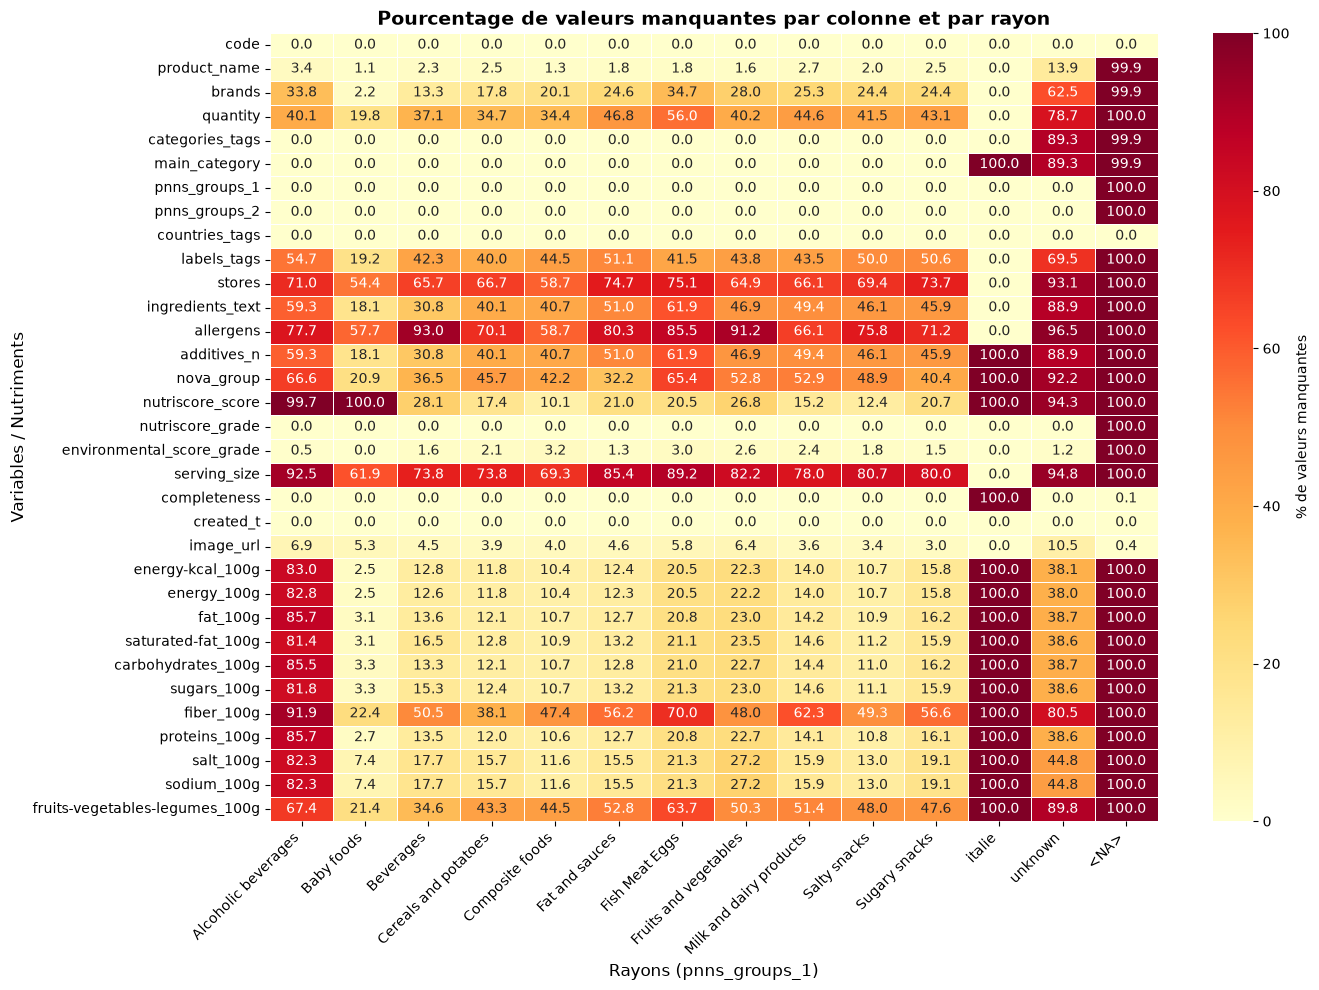

In [17]:
plt.figure(figsize=(14, 10))

sns.heatmap(
    par_rayon.T, 
    annot=True,
    cmap="YlOrRd",
    fmt=".1f",
    linewidths=0.5,
    cbar_kws={'label': '% de valeurs manquantes'}
)

plt.title("Pourcentage de valeurs manquantes par colonne et par rayon", fontsize=14, fontweight='bold')
plt.xlabel("Rayons (pnns_groups_1)", fontsize=12)
plt.ylabel("Variables / Nutriments", fontsize=12)
plt.xticks(rotation=45, ha="right")
plt.tight_layout()

plt.show()

### Par colonne : taux, dispersion entre rayons, lien avec la complétude (completeness)  
#### Surlignage taux de manquant > 10%

In [18]:
lignes = []
for col in colonnes:
    manque = df[col].isna()
    par_rayon = df.groupby("pnns_groups_1")[col].apply(lambda s: s.isna().mean() * 100)
    lignes.append({
        "colonne": col,
        "pct_manquant": round(manque.mean() * 100, 1),
        "min_rayon": round(par_rayon.min(), 1),
        "max_rayon": round(par_rayon.max(), 1),
        "completude_si_present": round(df.loc[~manque, "completeness"].median(), 3),
        "completude_si_manquant": round(df.loc[manque, "completeness"].median(), 3),
    })

df_stats = pd.DataFrame(lignes).set_index("colonne")

def surligner_lignes(row):
    if row['pct_manquant'] > 10:
        return ['background-color: #ff4d4d; color: black; font-weight: bold;'] * len(row)
    return [''] * len(row)

df_style = df_stats.style.apply(surligner_lignes, axis=1)
display(df_style)


,pct_manquant,min_rayon,max_rayon,completude_si_present,completude_si_manquant
colonne,,,,,
code,0.000000,0.000000,0.000000,0.375000,nan
product_name,10.400000,0.000000,13.900000,0.475000,0.075000
brands,46.500000,0.000000,62.500000,0.575000,0.275000
quantity,63.400000,0.000000,78.700000,0.688000,0.275000
categories_tags,49.700000,0.000000,89.300000,0.588000,0.275000
main_category,49.700000,0.000000,100.000000,0.588000,0.275000
pnns_groups_1,2.100000,0.000000,0.000000,0.388000,0.075000
pnns_groups_2,2.100000,0.000000,0.000000,0.388000,0.075000
countries_tags,0.000000,0.000000,0.000000,0.375000,nan


### MCAR (le manque ne dépend de rien) / MAR (le manque dépend d'une autre colonne)

In [19]:
df["ingredients_absents"] = df["ingredients_text"].isna()
for col in CSV_SELECTED_NUTRIMENT_COLUMNS:
    taux = df.groupby("ingredients_absents")[col].apply(lambda s: s.isna().mean() * 100).round(1)
    print(f"{col:35s} manquant : {taux[False]:5.1f} % quand les ingrédients sont là, {taux[True]:5.1f} % quand ils manquent")

energy-kcal_100g                    manquant :   9.5 % quand les ingrédients sont là,  38.7 % quand ils manquent
energy_100g                         manquant :   9.5 % quand les ingrédients sont là,  38.6 % quand ils manquent
fat_100g                            manquant :   9.8 % quand les ingrédients sont là,  39.3 % quand ils manquent
saturated-fat_100g                  manquant :  10.9 % quand les ingrédients sont là,  39.0 % quand ils manquent
carbohydrates_100g                  manquant :   9.7 % quand les ingrédients sont là,  39.3 % quand ils manquent
sugars_100g                         manquant :  10.3 % quand les ingrédients sont là,  39.1 % quand ils manquent
fiber_100g                          manquant :  33.1 % quand les ingrédients sont là,  85.6 % quand ils manquent
proteins_100g                       manquant :   9.8 % quand les ingrédients sont là,  39.2 % quand ils manquent
salt_100g                           manquant :  10.7 % quand les ingrédients sont là,  44.9 % qu

In [20]:
df["ingredients_absents"] = df["ingredients_text"].isna()
for col in ['allergens', 'additives_n', 'quantity', 'labels_tags']:
    taux = df.groupby("ingredients_absents")[col].apply(lambda s: s.isna().mean() * 100).round(1)
    print(f"{col:35s} manquant : {taux[False]:5.1f} % quand les ingrédients sont là, {taux[True]:5.1f} % quand ils manquent")

allergens                           manquant :  58.2 % quand les ingrédients sont là,  99.8 % quand ils manquent
additives_n                         manquant :   0.0 % quand les ingrédients sont là, 100.0 % quand ils manquent
quantity                            manquant :  23.1 % quand les ingrédients sont là,  80.0 % quand ils manquent
labels_tags                         manquant :  34.7 % quand les ingrédients sont là,  69.6 % quand ils manquent
